In [50]:
from google.cloud import bigquery
import pandas as pd
import seaborn as sns

# Criar cliente BigQuery
client = bigquery.Client(project="brazilian-ecommerce-488418")

In [6]:
# Consulta SQL ticket médio por categoria 
query = """
SELECT product_category_name, AVG(price) AS ticket_medio
FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` f
JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_product` p
USING(product_id)
GROUP BY product_category_name
ORDER BY ticket_medio DESC
"""

# Executa a consulta e transforma em DataFrame
df_ticket_category = client.query(query).to_dataframe()

# Mostrar resultados
print(df_ticket_category.head())

c:\Users\jonat\OneDrive\Documentos\Brazilian E-Commerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


         product_category_name  ticket_medio
0                          pcs   1071.016020
1  portateis_casa_forno_e_cafe    638.213151
2           eletrodomesticos_2    470.358772
3    agro_industria_e_comercio    342.553883
4        instrumentos_musicais    281.656465


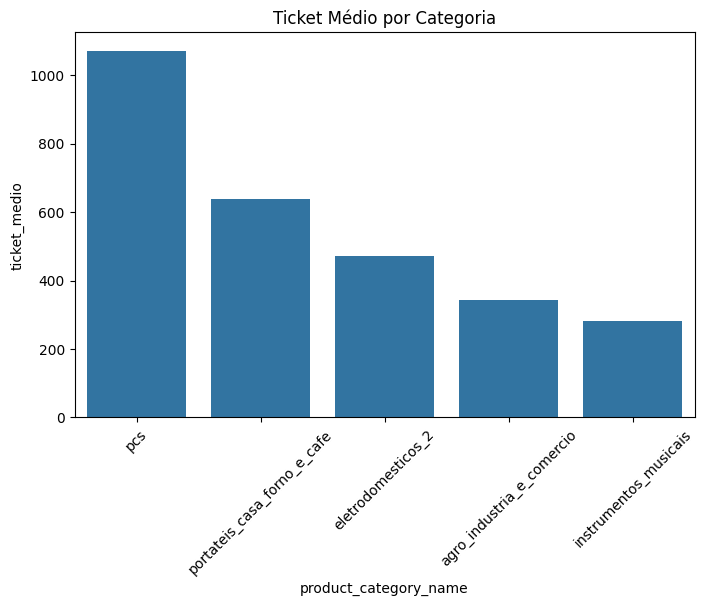

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de ticket médio por cidade
plt.figure(figsize=(8,5))
sns.barplot(data=df_ticket_category.head(5), x='product_category_name', y='ticket_medio')
plt.xticks(rotation=45)
plt.title('Ticket Médio por Categoria')
plt.show()

In [13]:
# categorias mais compradas
query = """
    SELECT 
        p.product_category_name,
        COUNT(*) AS produtos_vendidos 
    FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
    JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_product`AS p
        ON f.product_id = p.product_id
    GROUP BY p.product_category_name
    ORDER BY produtos_vendidos DESC
"""

df_best_selling_category = client.query(query).to_dataframe()

print(df_best_selling_category)


c:\Users\jonat\OneDrive\Documentos\Brazilian E-Commerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


            product_category_name  produtos_vendidos
0                 cama_mesa_banho              43216
1                    beleza_saude              37532
2                   esporte_lazer              33400
3                moveis_decoracao              32168
4          informatica_acessorios              30332
..                            ...                ...
69              cds_dvds_musicais                 56
70                     la_cuisine                 52
71                       pc_gamer                 32
72  fashion_roupa_infanto_juvenil                 28
73             seguros_e_servicos                  8

[74 rows x 2 columns]


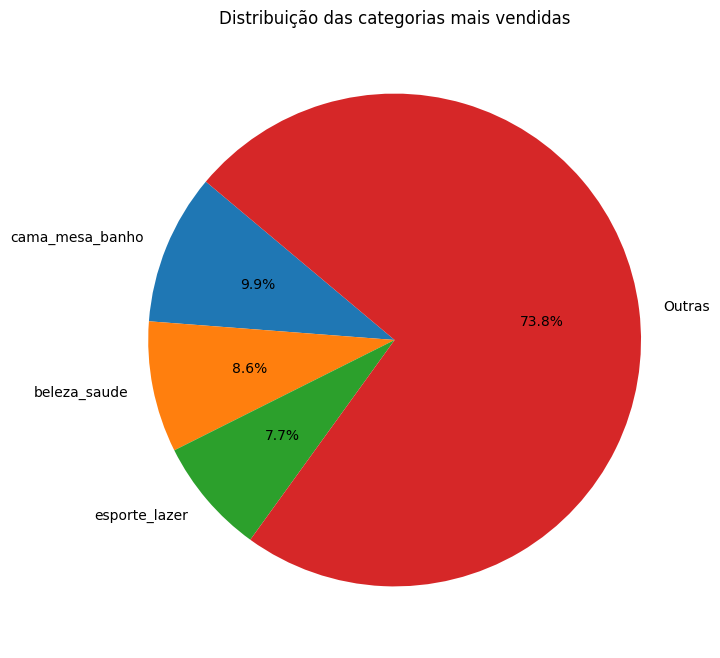

In [31]:
top3 = df_best_selling_category.head(3)
rest = df_best_selling_category[3:]

df_others = pd.DataFrame([{
    'product_category_name': 'Outras',
    'produtos_vendidos': rest['produtos_vendidos'].sum()
}])

df_pie = pd.concat([top3, df_others], ignore_index=True)

plt.figure(figsize=(8,8))
plt.pie(
    df_pie['produtos_vendidos'],
    labels=df_pie['product_category_name'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Distribuição das categorias mais vendidas')
plt.show()

In [35]:
# cidades com mais vendas e quanto venderam
query = """
    SELECT 
        s.seller_city,
        SUM(f.price) AS vendas_totais
    FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
    JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_seller` AS s
        ON f.seller_id = s.seller_id
    GROUP BY s.seller_city
    ORDER BY vendas_totais DESC
"""

df_sales_per_city = client.query(query).to_dataframe()
print(df_sales_per_city)

c:\Users\jonat\OneDrive\Documentos\Brazilian E-Commerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


        seller_city  vendas_totais
0         sao paulo   1.039443e+07
1          ibitinga   2.422384e+06
2          curitiba   1.827055e+06
3    rio de janeiro   1.355494e+06
4         guarulhos   1.265385e+06
..              ...            ...
588       cascavael   8.796000e+01
589         resende   7.996000e+01
590    floranopolis   7.992000e+01
591          jarinu   5.852000e+01
592        palotina   3.996000e+01

[593 rows x 2 columns]


C:\Users\jonat\AppData\Local\Temp\ipykernel_23164\2074874890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


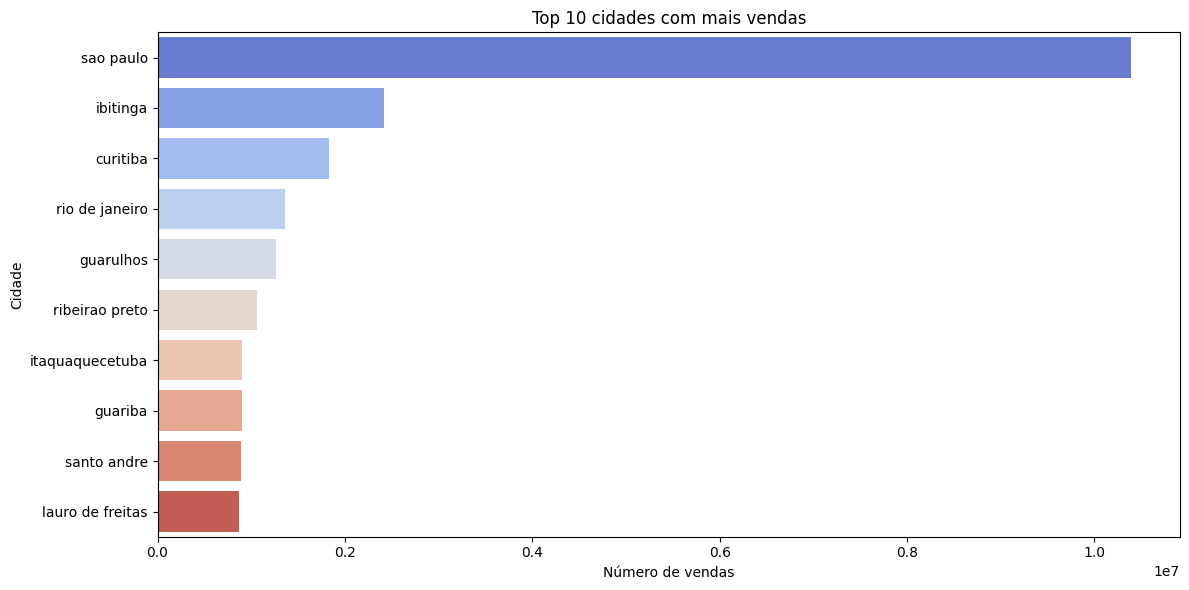

In [38]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_sales_per_city.head(10),
    x='vendas_totais',
    y='seller_city',
    palette='coolwarm'
)
plt.title('Top 10 cidades com mais vendas')
plt.xlabel('Número de vendas')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()

In [63]:
# tendencia de vendas por período

query = """
    SELECT 
        t.month,
        SUM(f.price) AS vendas_mes
    FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
    JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_time` AS t
        ON f.time_id = t.time_id
    GROUP BY t.month
    ORDER BY vendas_mes DESC
""" 

df_month_sales = client.query(query).to_dataframe()

print(df_month_sales)


c:\Users\jonat\OneDrive\Documentos\Brazilian E-Commerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


    month  vendas_mes
0       5  4367554.92
1       8  4140031.95
2       7  3974968.32
3       4  3916351.86
4       3  3882890.10
5       6  3817280.40
6       2  3144384.63
7       1  3069331.41
8      11  2937714.57
9      12  2139340.71
10     10  2043704.04
11      9  1807655.94


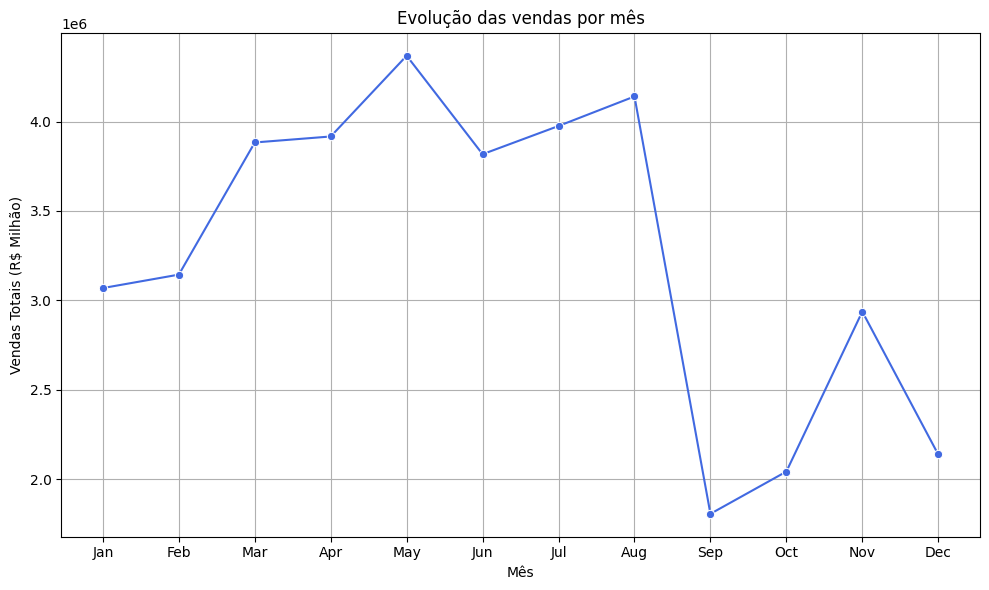

In [68]:
import calendar

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_month_sales,
    x='month',
    y='vendas_mes',
    marker='o',  # mostra pontos em cada mês
    color='royalblue'
)
meses = [calendar.month_abbr[i] for i in range(1, 13)]  # abreviação Jan, Feb...
plt.xticks(ticks=range(1,13), labels=meses)
plt.title('Evolução das vendas por mês')
plt.xlabel('Mês')
plt.ylabel('Vendas Totais (R$ Milhão)')
plt.grid(True)
plt.tight_layout()
plt.show()